## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [1]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

In [2]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df_house_price = pd.read_csv(StringIO(csv_content))

# Display the first few rows
display(df_house_price)


In [3]:
df_house_price.head(10)

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,48,8.297631,5.935734,602134.8167
1,287.678577,1,2,1,37,6.061466,10.827392,591425.1354
2,232.998485,1,3,2,14,2.911442,6.904599,464478.6969
3,199.664621,5,2,2,17,2.070949,8.284019,583105.6560
4,89.004660,4,3,3,34,1.523278,14.648277,619879.1425
5,88.998630,5,3,2,36,8.994552,17.633250,670386.8044
6,64.520903,4,3,1,32,7.101354,2.429908,523827.1256
7,266.544036,5,1,3,39,9.373784,12.692785,875352.5452
8,200.278753,5,1,1,32,6.032918,11.642876,738269.8523
9,227.018144,3,2,1,29,4.734009,2.368301,490552.6812


In [4]:
# Check for missing values
missing_values = df_house_price.isnull()

## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

In [5]:
df_house_price.describe()


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


In [6]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.3 MB/s eta 0:00:00


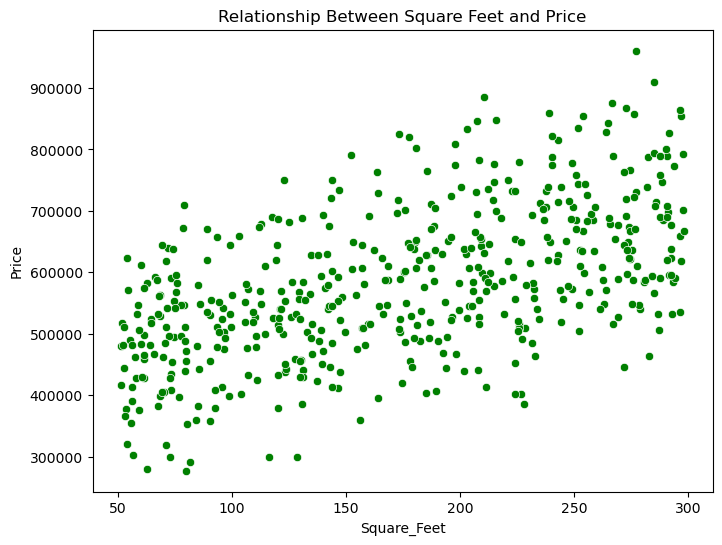

In [7]:
# Scatter plot to visualise the relationship between Square Feet and Price

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Square_Feet', y='Price', data=df_house_price, color='green')
plt.title('Relationship Between Square Feet and Price')
plt.xlabel('Square_Feet')
plt.ylabel('Price')
plt.show()


## Analysis notes
 The scatter plot shows a positive relationship between square feet and house price.
 As the size of a house increases, the price generally increases as well.
 The data points follow an upward trend, though there is some spread in prices for similar-sized houses.

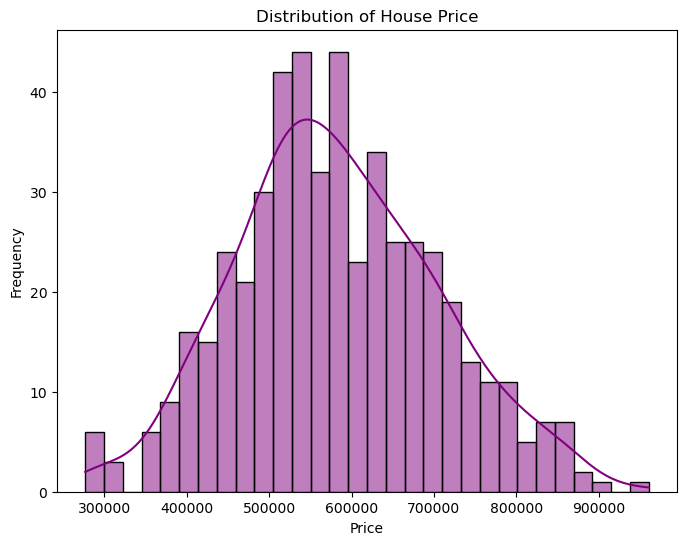

In [8]:
# Histogram to visualise the distribution of Price
plt.figure(figsize=(8, 6))
df_house_price['Price'] = df_house_price['Price']
sns.histplot(df_house_price['Price'], bins=30, color='purple', kde=True)
plt.title('Distribution of House Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Analysis notes for histogram
- House prices are approximately normally distributed, with a slight right skew, indicating that most properties fall within a mid-price range while fewer high-priced properties exist.
- The majority of houses are clustered around the $500,000 - $600,000 range, suggesting this is the most common and in-demand price bracket.
- Most housing markets tend to concentrate around an affordable mid-range, where buyer demand is strongest.

                    Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
Square_Feet            1.000000     -0.049918      -0.001667    0.056873   
Num_Bedrooms          -0.049918      1.000000      -0.056808    0.009088   
Num_Bathrooms         -0.001667     -0.056808       1.000000   -0.040895   
Num_Floors             0.056873      0.009088      -0.040895    1.000000   
Garage_Size           -0.051598     -0.065481       0.055707   -0.082763   
Location_Score        -0.035270     -0.000357      -0.013855    0.019928   
Distance_to_Center     0.093080      0.040511      -0.082571    0.035164   
Price                  0.558604      0.563973       0.156689    0.177435   

                    Garage_Size  Location_Score  Distance_to_Center     Price  
Square_Feet           -0.051598       -0.035270            0.093080  0.558604  
Num_Bedrooms          -0.065481       -0.000357            0.040511  0.563973  
Num_Bathrooms          0.055707       -0.013855           -0.082571  0.1566

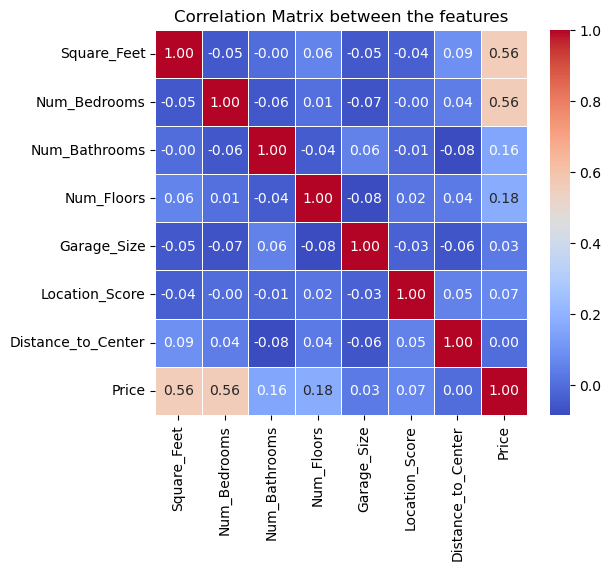

In [9]:
# Calculate correlation between 'UnitsSold' and 'Sales'
correlation = df_house_price.corr()

# Display the correlation matrix
print(correlation)

# Create a heatmap for the correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix between the features')
plt.show()

### Analysis notes for correlation matrix
- Square_Feet and Num_Bedrooms have the strongest positive correlation with Price (0.56 each).
- Num_Bathrooms and Num_Floors show weak positive correlations with Price (0.16 and 0.18).
- Garage_Size, Location_Score, and Distance_to_Center have little to no correlation with  Price.
- Most features have low correlations with each other.
- When predicting or explaining house prices, Square_Feet and Num_Bedrooms are the most important features to focus on.

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

In [10]:
# Features (X) and target (y)
X = df_house_price[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center']]
y = df_house_price['Price']


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split data
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (400, 7), Testing Data: (100, 7)


In [12]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model_lr = LinearRegression()

# Fit the model on the training data
model_lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = model_lr.predict(X_test)



🏃 View run silly_tent_fq7035zt at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/527f0dc2-f25a-4326-9667-ea369e301e5c/runs/2411d80e-b767-4f2a-85d3-b6f2c8805c16
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/527f0dc2-f25a-4326-9667-ea369e301e5c


In [13]:
# Create a DataFrame for Actual vs Predicted prices for both models

results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr
})

# Display the table
print(results_df)  # Shows the first few rows of the table

# Calculate RMSE for MLR
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Root Mean Squared Error (RMSE) for MLR: {rmse_lr}")

     Actual Price  Predicted Price (MLR)
361   591058.7089          525669.926934
73    667693.0003          668141.051861
374   532377.5802          467168.904743
155   478489.2990          498375.548472
104   730197.4806          691359.973840
..            ...                    ...
347   464849.9178          493645.118779
86    572360.6499          643248.170875
75    557752.8374          454235.083741
438   649930.0523          564489.566281
15    523527.9747          456453.859955

[100 rows x 2 columns]
Root Mean Squared Error (RMSE) for MLR: 63952.37599755184


### Analysis
The predicted prices from the multiple linear regression (MLR) model are generally close to the actual prices, showing the model captures the main trends well.
- The RMSE of about 63,952 shows the average prediction error is around $64,000

In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

print(
    f"Interpretation: On average, the model’s predictions deviate from the actual "
    f"values by approximately {rmse:.2f} units. A lower RMSE indicates better "
    f"model performance, as predictions are closer to the true values."
)



Root Mean Squared Error (RMSE): 63952.38
Interpretation: On average, the model’s predictions deviate from the actual values by approximately 63952.38 units. A lower RMSE indicates better model performance, as predictions are closer to the true values.


In [18]:
# Create a table with Actual vs Predicted Prices for Random Forest
results_df_rf = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Display the table
print(results_df_rf.head())

# Calculate RMSE for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    500627.243247
73    667693.0003                    654256.956307
374   532377.5802                    561434.354749
155   478489.2990                    484593.849958
104   730197.4806                    757536.282477
Root Mean Squared Error (RMSE) for Random Forest: 72013.1303207925


 ### Analysis

- The Random Forest model's predicted prices are generally close to actual prices, capturing overall trends.
- The RMSE of about 72,013 indicates the average prediction error is around $72,000, which is higher than the MLR model's error.

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Fit the Random Forest model on the training data
model_rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test)


🏃 View run affable_fox_f0pxzj83 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/527f0dc2-f25a-4326-9667-ea369e301e5c/runs/043948d6-6e44-4ec1-b2a8-e2b2dbbcadcb
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/527f0dc2-f25a-4326-9667-ea369e301e5c


In [19]:
# Create a table with Actual vs Predicted Prices for Random Forest
results_df_rf = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Display the table
print(results_df_rf.head())

# Calculate RMSE for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    500627.243247
73    667693.0003                    654256.956307
374   532377.5802                    561434.354749
155   478489.2990                    484593.849958
104   730197.4806                    757536.282477
Root Mean Squared Error (RMSE) for Random Forest: 72013.1303207925


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Fit the Random Forest model on the training data
model_rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test)

🏃 View run kind_ice_bygkv0jj at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/527f0dc2-f25a-4326-9667-ea369e301e5c/runs/2b01eccb-4e81-4537-af45-edf8938bdf54
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/527f0dc2-f25a-4326-9667-ea369e301e5c


In [21]:
# Compare the RMSE of both models
print(f"RMSE for MLR: {rmse_lr}")
print(f"RMSE for Random Forest: {rmse_rf}")

# Provide insights
if rmse_lr < rmse_rf:
    print("The Multiple Linear Regression model performs better based on RMSE.")
else:
    print("The Random Forest model performs better based on RMSE.")

RMSE for MLR: 63952.37599755184
RMSE for Random Forest: 72013.1303207925
The Multiple Linear Regression model performs better based on RMSE.


## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

In [22]:


print("=" * 70)
print("Step 5: Conclusions and Insights")
print("=" * 70)

Step 5: Conclusions and Insights


Based on the RMSE and visualisations - the Multiple Linear Regression (MLR) model works better than the Random Forest Regression model (RMSE of 63952.37599755184 vs 72013.1303207925)

We can chaulk this up to the following reasons:
- Sample Size: With a limited sample size of data (500 entries) the Random Forest does not have enough data to build robust decision trees. 
- Linear Relationship: As the scatter plot in Step 2.2 shows, there is a clear relationship between the number of Square Feet and the Price of the house. The link between the variables on the price of the house are not complex or non-linear, meaning the MLR model the more logical choice.

In [2]:
print("=" * 63)
print("Recommendations to improve the models:")
print("-" * 63)

Recommendations to improve the models:
---------------------------------------------------------------


To improve the Random Forest Model will can do the following things:
1. Add more data (Random Forest works better with more data for decision trees)
2. Create more columns to interact with (we can try Square Feet x Number of Bedrooms) to create more complex patterns
3. We can try and adjust the settings to give ourselves more n_estimators to capture data with (instead of '200' we could try '300' or even '500').

To improve the Multiple Linear Regression Model we can do the following things:
1. Handle outliers: Look for house prices that are extremely low or high and decide whether to include in the dataset or not. Outliers will skew the data
1. Find more features: Other factors will affect House Price such as decile of school zone, median house price of neighbourhood, Age of house, Whether in a flood zone or not. These additional columns would create a more accurate measure.

Importantly: As we are not experts in the world of house prices, we should consult professionals (Real Estate Agents) who can provide what data we should be collecting to create a more accurate predictor.
